# Importación de librerías.

In [ ]:
!pip install minisom

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler

# Inicio

Grupo:
* Ana Gónzales Núñez
* Javier Argenta Cañas
* Luis Sánchez Agulla
* Miguel Ciordia Isac

## Descripción del problema

Entrenamiento de una RNN basada en arquitectura SOM para poder clasificar un conjunto de datos propios de los países.


## Importación de datos

In [4]:
df = pd.read_csv("world_data.csv")

## Previsualización de los datos

Buscamos previsualizar los datos del CSV:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


Observamos dentro del conjunto de datos una única variable categórica que representa el nombre de cada país usado dentro del dataset.

Observando la descripción básica del conjunto de datos dado, podemos referenciar que hay un conjunto de instancias que representan una inflación mínima inferior a 0 (negativa). Dada la naturaleza del dato, podemos concluir que a pesar de ser "atípico" en concepto, es posible dentro del mundo qu eexista dicho caso, pasando a ser conocido como "deflación."

In [7]:
valores_negativos = df[df['inflation'] < 0]
print(valores_negativos)

            country  child_mort  exports  health  imports  income  inflation  \
10          Bahamas        13.8     35.0    7.89     43.7   22900     -0.393   
43   Czech Republic         3.4     66.0    7.88     62.9   28300     -1.430   
73          Ireland         4.2    103.0    9.19     86.5   45700     -3.220   
77            Japan         3.2     15.0    9.49     13.6   35800     -1.900   
85           Latvia         7.8     53.7    6.68     55.1   18300     -0.812   
131      Seychelles        14.4     93.8    3.40    108.0   20400     -4.210   
133       Singapore         2.8    200.0    3.96    174.0   72100     -0.046   
135        Slovenia         3.2     64.3    9.41     62.9   28700     -0.987   

     life_expec  total_fer   gdpp  
10         73.8       1.86  28000  
43         77.5       1.51  19800  
73         80.4       2.05  48700  
77         82.8       1.39  44500  
85         73.1       1.36  11300  
131        73.4       2.17  10800  
133        82.7       1.15 

Dentro del conjunto de datos totales, podemos identificar hasta 8 países distintos que presentan un valor atípico dentro del concepto de inflación: Bahamas, Republica Checa, Irlanda, Japón, Letonia, Seychelles, Singapúr y Eslovenia. A pesar de presentar dichos valores, como se ha indicado previamente, se mantiene dichos valores dado que son plausibles.

Para poder realizar una primera visualización de los datos del dataframe, en comparación con el resto de variables, hacemos una gráfica de `pairplot`. Empleando esta gráfica, buscamos sacar conclusiones como las proporcionalidades entre las variables, viendo si tienen relaciones lineales o de otro tipo.

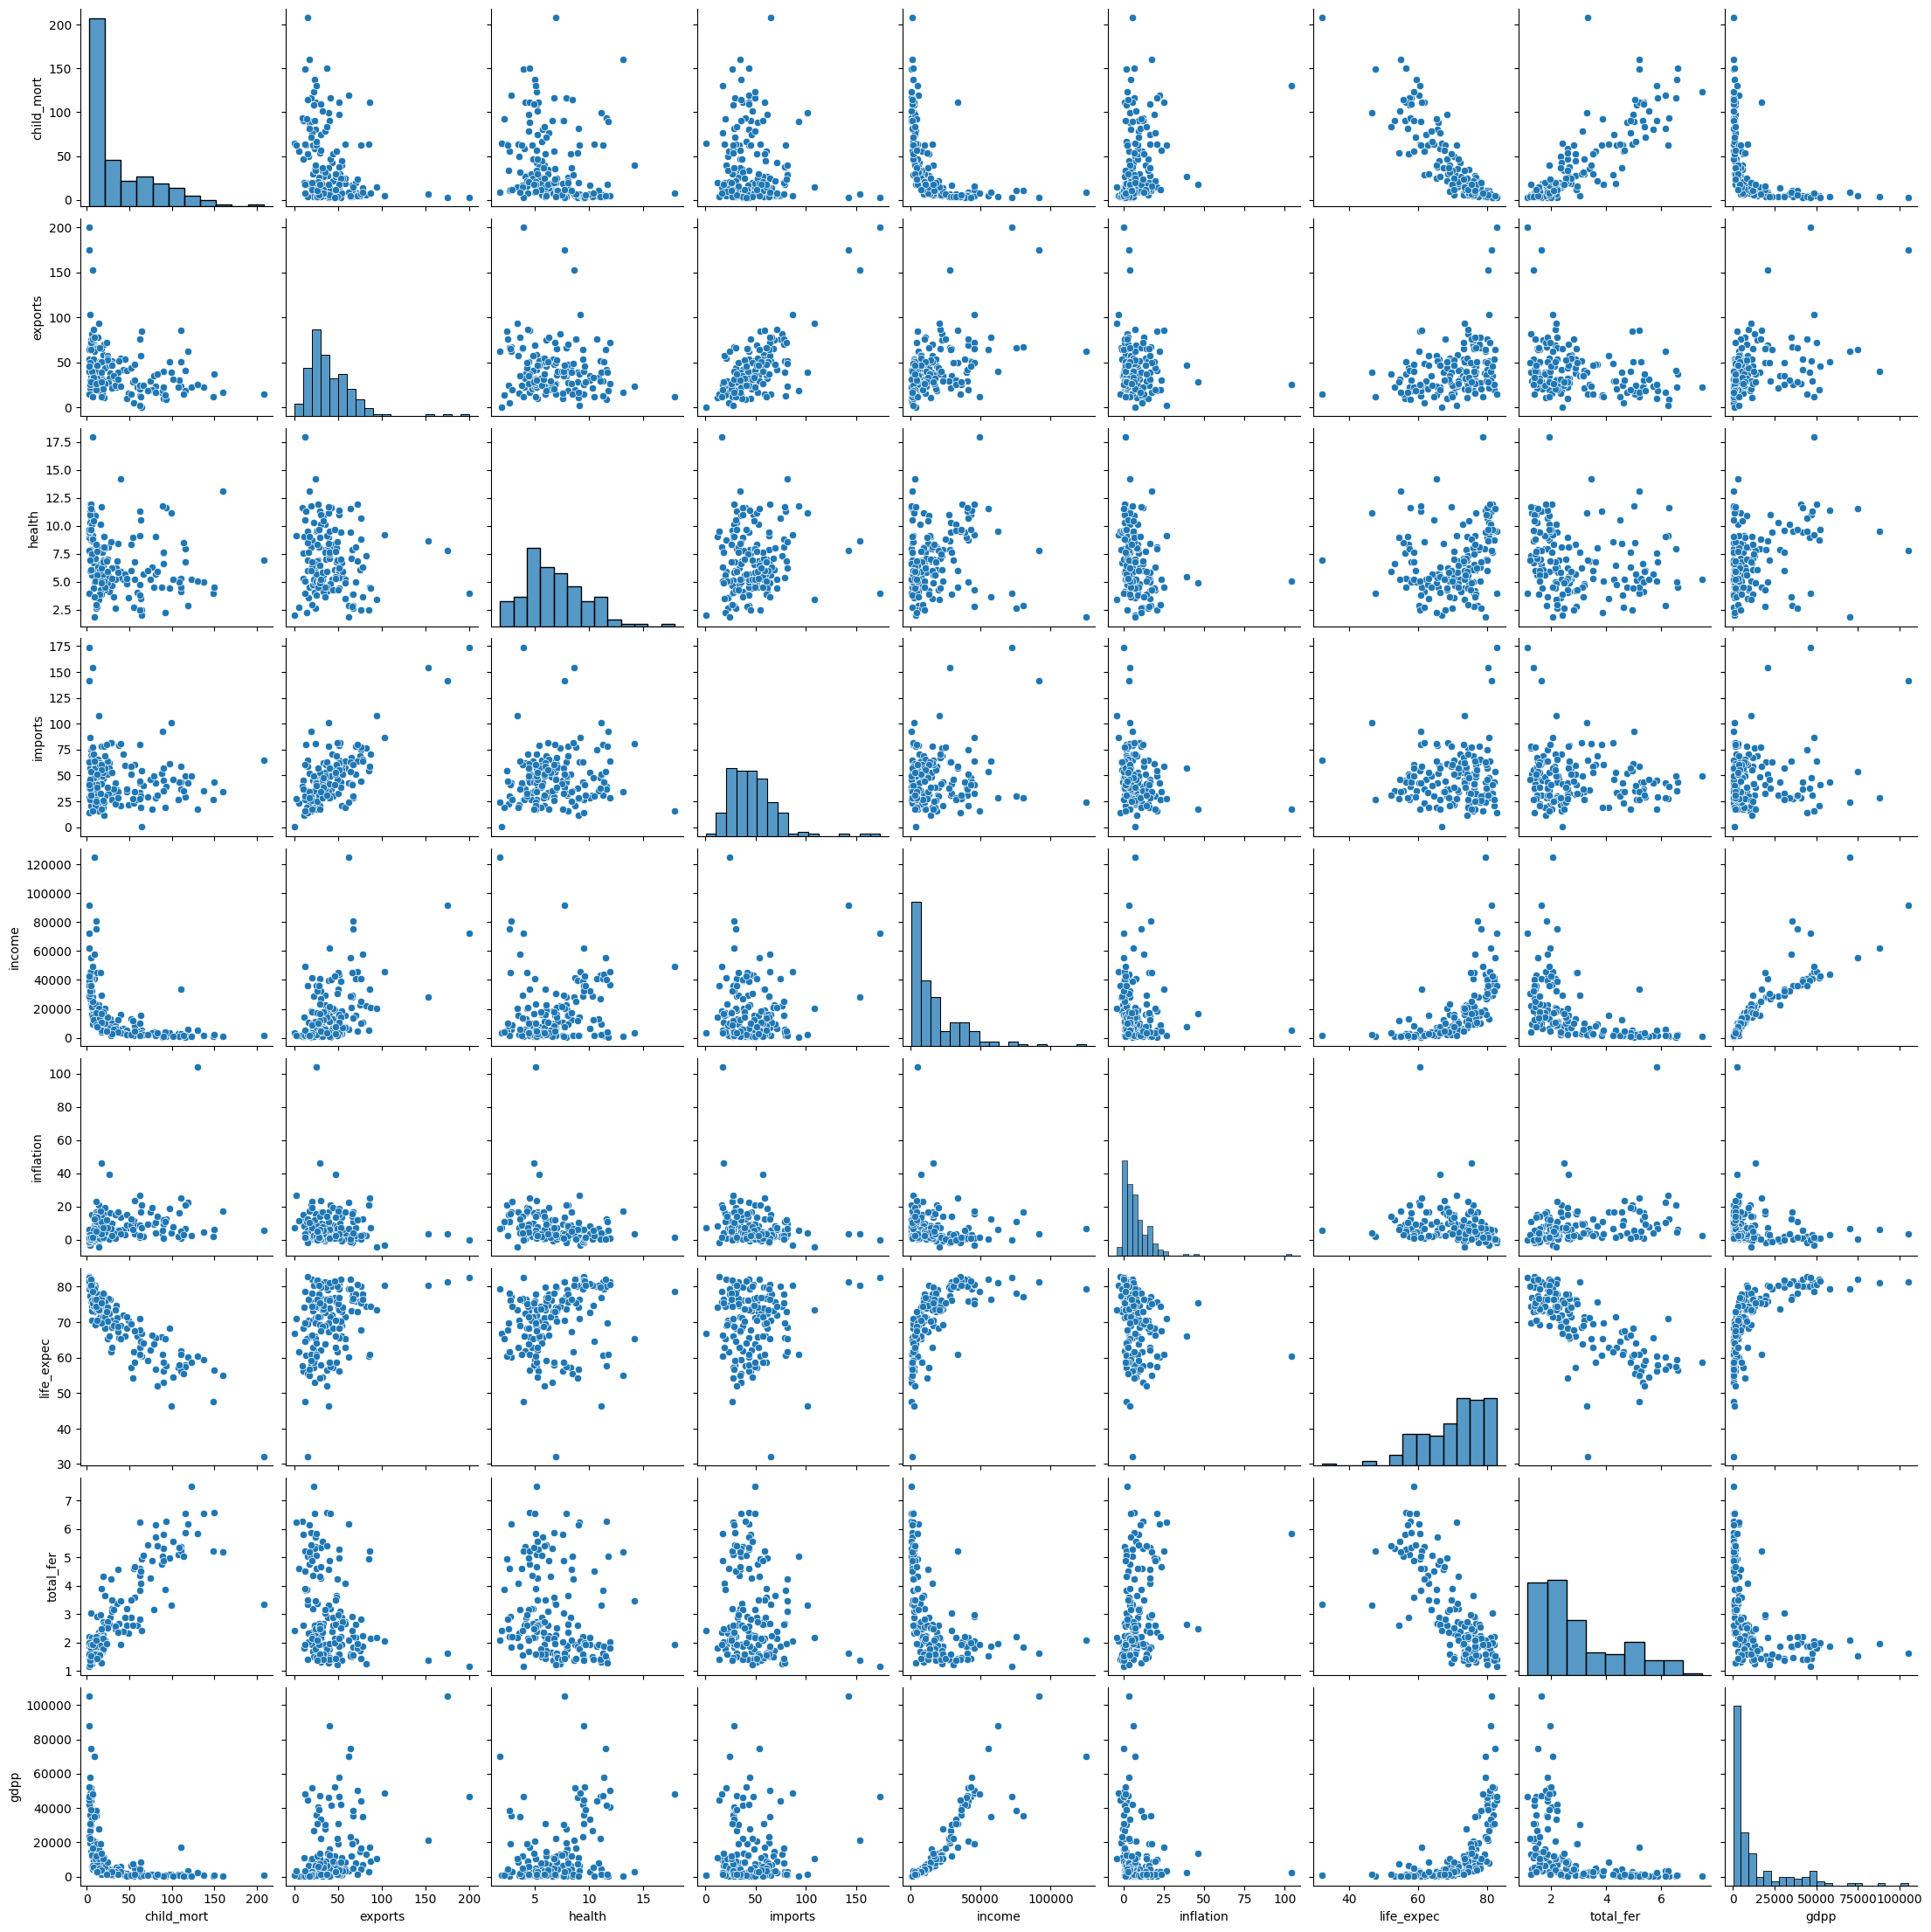

In [18]:
sns.pairplot(df)
plt.show()

Dentro de las gráficas de pariplot, podemos observar como las variables mantienen, en su mayoría, una relación no lineal, destacando casos como las de las relaciones propias de la variable `gdpp`: estas contienen, en ciertos casos, de manera visual una relación exponencial o logarítmica en según que situaciones, como lo pueden ser la relación con `child_mort` o `inflation`.

Para poder estudiar en mayor profundidad la distribución de cada una de ls variables, tratamos de observar sus histogramas, acompañados de un gráfico KDE, el cual nos simboliza la distribución de la variable a lo largo de sus valores.

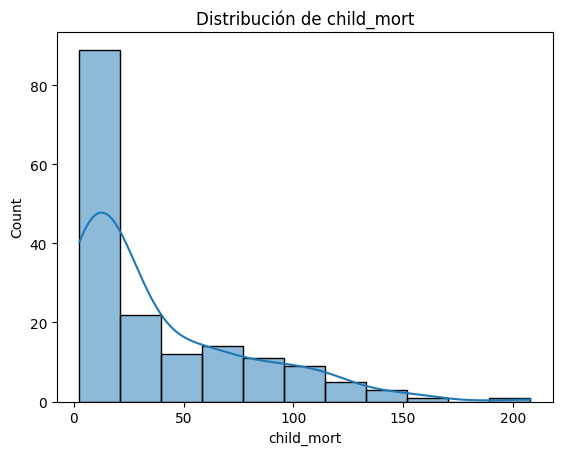

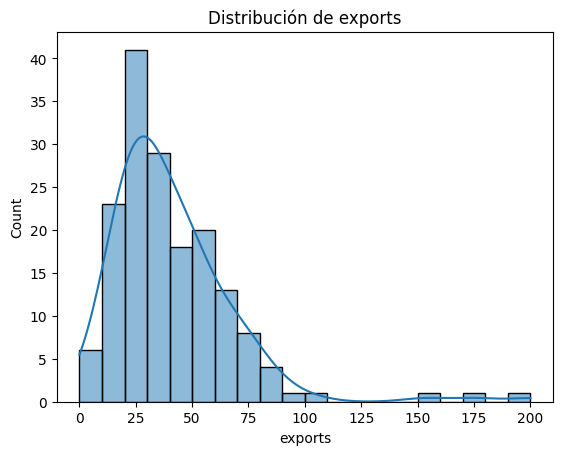

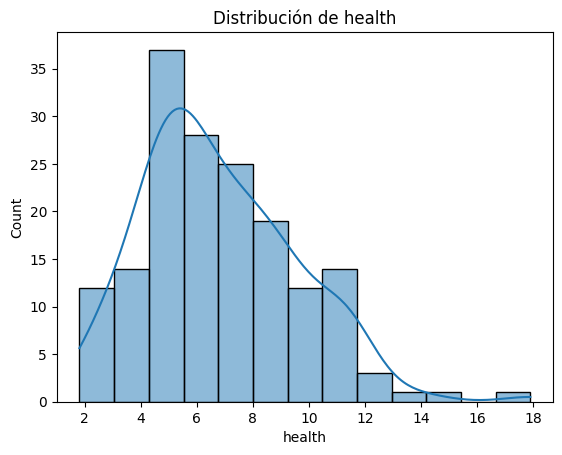

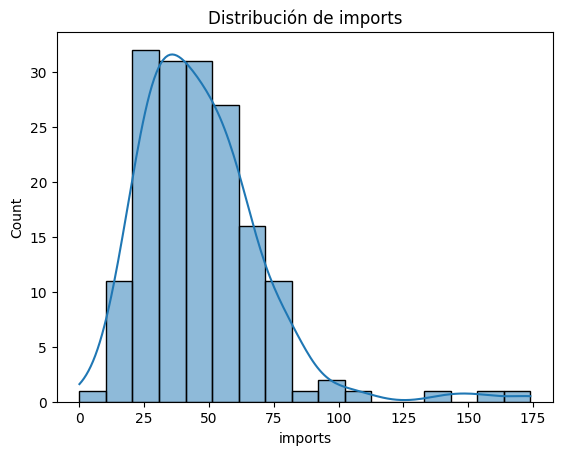

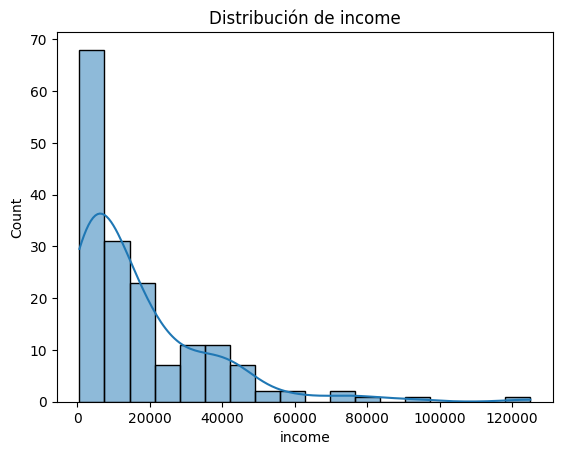

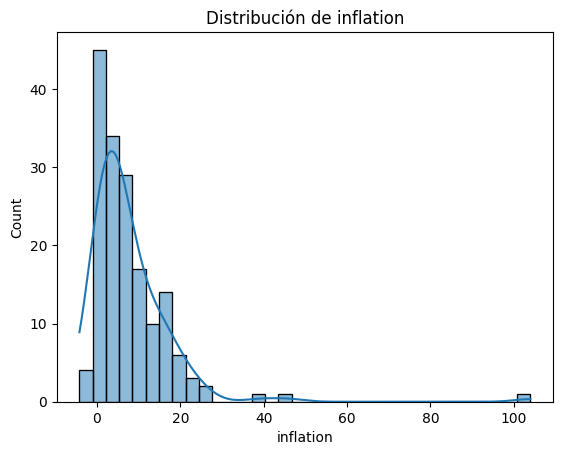

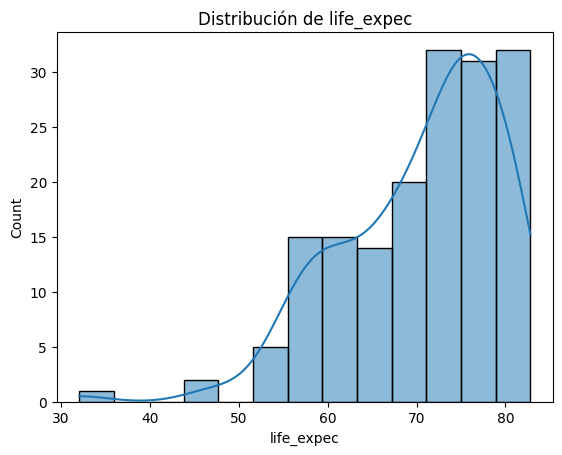

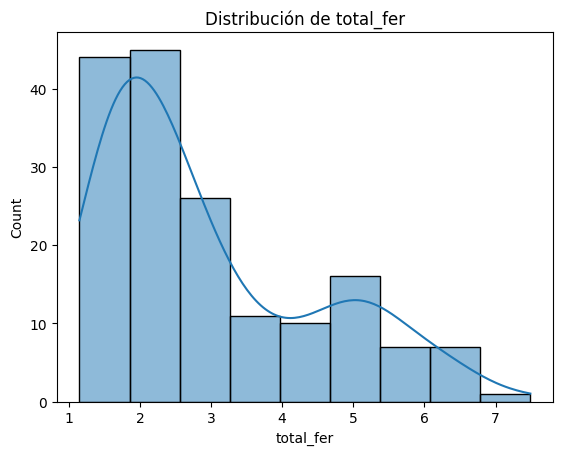

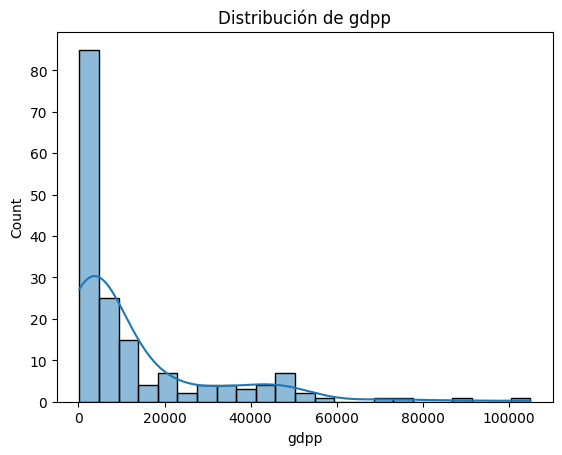

In [8]:
columnas = df.columns[1:]

for col in columnas:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.show()

Podemos destacar que en la comparativa de valores y distribuciones de cada una de las variables, presentan en su mayoría una disparidad de rangos. En concreto, comprendemos que hay ciertas variables como lo son `gdpp`, la cual contiene un rango de entre 0 a 100.000. Por otro lado, variables como `total_fer` comprenden un rango solo entre 0 y 7, presentando solo en el caso de la variable `inflation` un valor negativo dentro de su rango (explorado y justificado previamente).
Como característica común, todas las distribuciones parecen presentar una mayor tendencia a números más bajos dentro de su propia distribución, siendo la mediana de los datos y la media menor a la que se podría esperar dado el rango de valores, siendo este último más convergente hacia valores superiores.

Visualizamos el conjunto de datos, para poder discernir la presencia de valores nulos a lo largo de todo el dataset.

In [9]:
null_values = df.isnull().sum()
print(null_values)

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


Como podemos apreciar, el dataset no presenta ningún dato nulo a lo largo de todo el conjunto de instancias dadas, de manera que la limpieza de datos no hace falta que se ambiente en la sustitución de datos, inclusión de nuevos o reducción del tamaño del dataset.

Exploramos del conjunto de datos para poder destacar los outliers en cada una de las variables. Para poder hacerlo, vamos a calcular los quartiles Q1, Q3 y el rango IQR. Sacando dichas variables estadísticas y apoyandonos en ellas, buscamos saber cuantas instancias son consideradas atípicas.

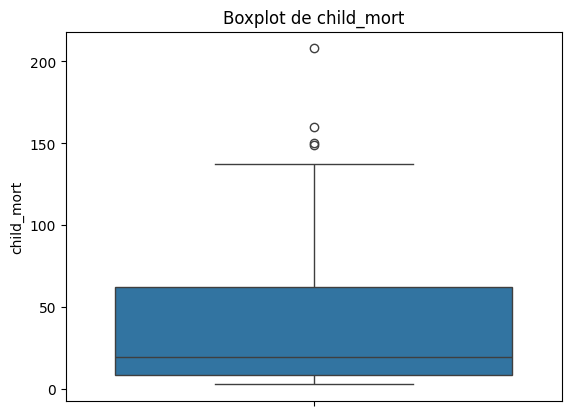

Outliers en la columna:  child_mort . Cantidad de outliers en dicha columna:  4 



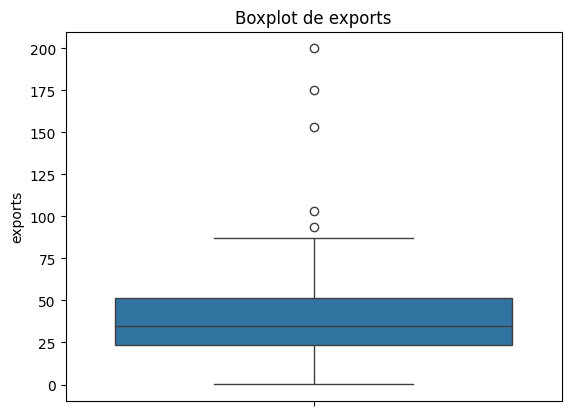

Outliers en la columna:  exports . Cantidad de outliers en dicha columna:  5 



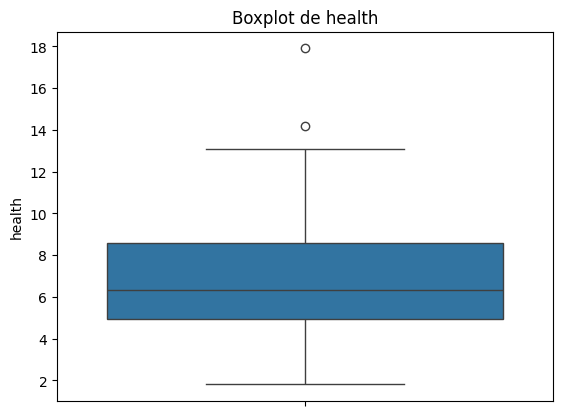

Outliers en la columna:  health . Cantidad de outliers en dicha columna:  2 



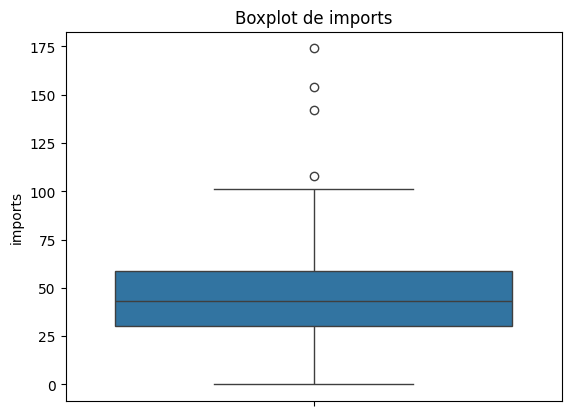

Outliers en la columna:  imports . Cantidad de outliers en dicha columna:  4 



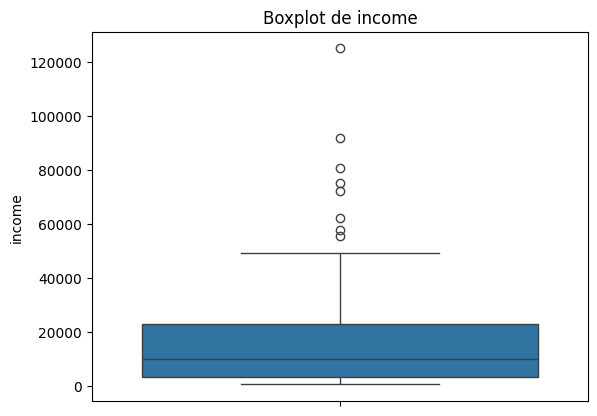

Outliers en la columna:  income . Cantidad de outliers en dicha columna:  8 



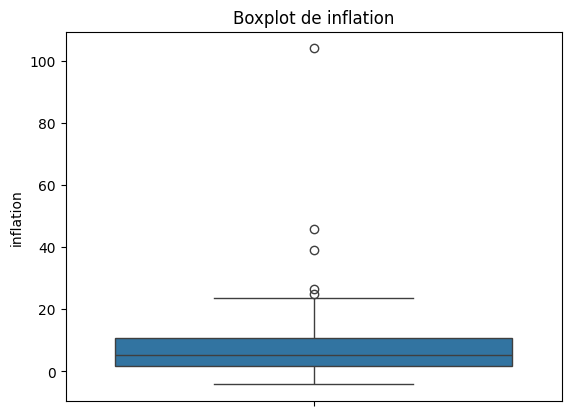

Outliers en la columna:  inflation . Cantidad de outliers en dicha columna:  5 



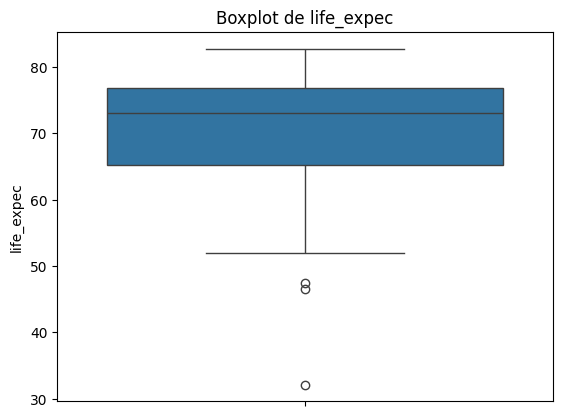

Outliers en la columna:  life_expec . Cantidad de outliers en dicha columna:  3 



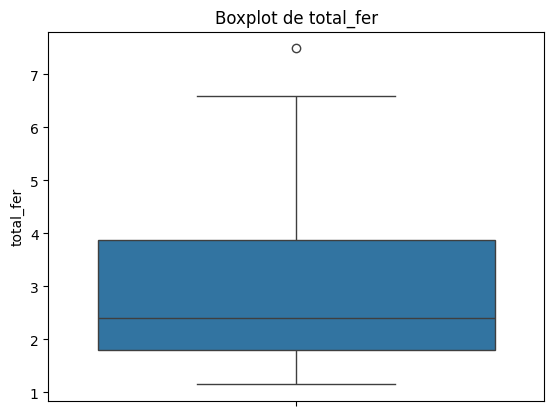

Outliers en la columna:  total_fer . Cantidad de outliers en dicha columna:  1 



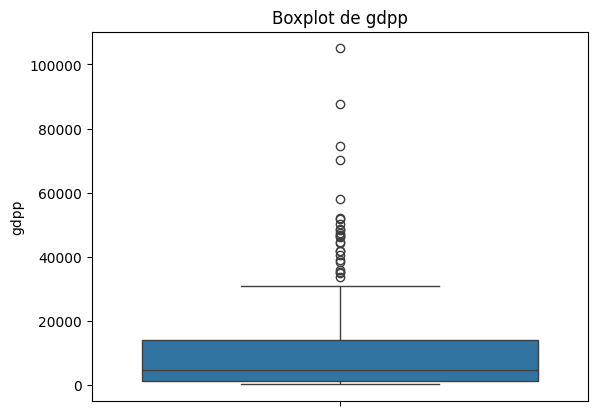

Outliers en la columna:  gdpp . Cantidad de outliers en dicha columna:  25 



In [16]:
df_sin_country = df.drop('country', axis = 1)

for col in df_sin_country:
  Q1 = df_sin_country[col].quantile(0.25)
  Q3 = df_sin_country[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df_sin_country[(df_sin_country[col] < lower_bound) | (df_sin_country[col] > upper_bound)]
  contador_outliers = len(outliers)
  sns.boxplot(df_sin_country[col])
  plt.title(f'Boxplot de {col}')
  plt.show()
  print("Outliers en la columna: ", col, ". Cantidad de outliers en dicha columna: ", contador_outliers, "\n")

Dentro del dataset que se nos presenta, podemos estudiar las correlaciones propias de entre cada una de las variables, de forma que podamos posteriormente decidir cuales seleccionamos para poder realizar el entrenamiento de la Red Neuronal.

Dada la naturaleza de los datos, hay que tener en cuenta que las variables altamente correlacionadas pueden incurrir en datos redundantes, haciendo que se puedan seleccionar un conjunto concreto de atributos a raíz de dicho juicio.

Además, podemos sacar una tabla de correlaciones importantes entre variables para poder guiar el estudio de este aspecto del dataset.

<Axes: >

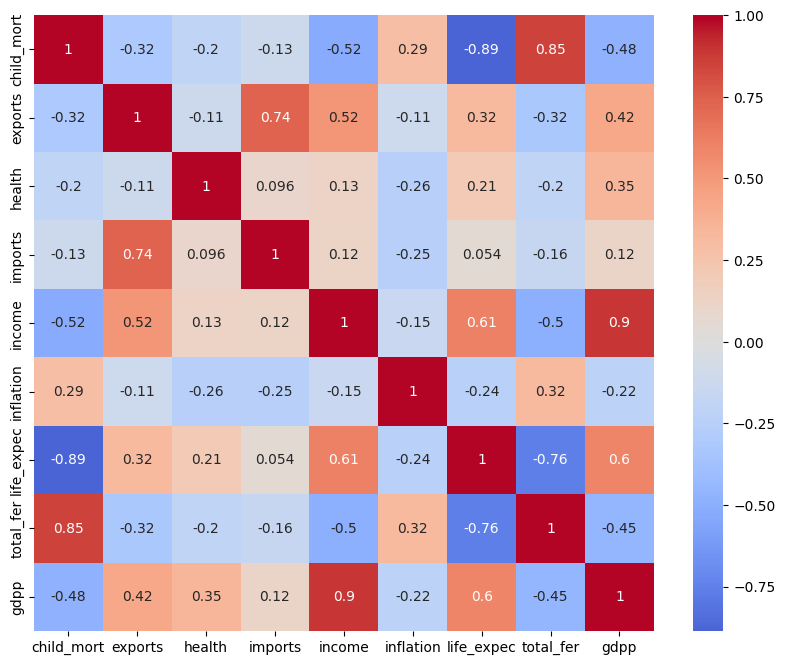

In [12]:
df_sin_country = df.drop('country', axis=1)

corr_matrix = df_sin_country.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    cbar=True
)

In [22]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_sin_country)

# Implementación

Buscamos realizar una implementación de un mapa autorganizado o SOM para poder clasificar los distintos países que se encuentran dentro del dataframe. Para poder configurar correctamente una arquitectura de red neuronal estilo SOM, empleamos la librería `minisom`, de la cual extraemos la configuración principal.

Para poder configurar comodamente la SOM, buscamos unas dimensiones estándares que se amolden a la estructura de los datos que comprendemos.

Dentro del conjunto de hiperparámetros críticos para el entrenamiento de la red neuronal, debemos de tener en cuenta tanto el `ratio de aprendizaje`, `sigma o radio de vecindad`, `función de vecindad`, entre otros. Las decisiones de configuración de cada uno de los hiperparámetros están supeditadas a una evaluación para poder identificar el mejor modelo en función de los datos que poseemos.

In [42]:
altura_mapa = 4 # Valor de la dimensión 'altura' dentro de la SOM
anchura_mapa = 4 # Valor de la dimensión 'anchura' dentro de la SOM
columnas_dataset = df_scaled.shape[1] # Extraemos el conjunto de columnas del dataframe

som = MiniSom(
    x=altura_mapa,
    y=anchura_mapa,
    input_len=columnas_dataset,
    sigma=1.0,
    learning_rate=0.1,
    neighborhood_function='gaussian',
    random_seed=42
)

som.pca_weights_init(df_scaled)

print("Entrenando el SOM...")
som.train_random(data=df_scaled, num_iteration=500)
print("¡Entrenamiento completado!")

Entrenando el SOM...
¡Entrenamiento completado!


Teniendo el SOM ya entrenado con los datos que poseemos, visualizamos la distribución de los datos en cada una de las neuronas, con el fin de poder identificar cuales son las neuronas que más datos recogen, así como las que se quedan vacías. Para poder estudiar esto mismo, realizamos un mapa de calor con la SOM ya entrenada.

<Axes: >

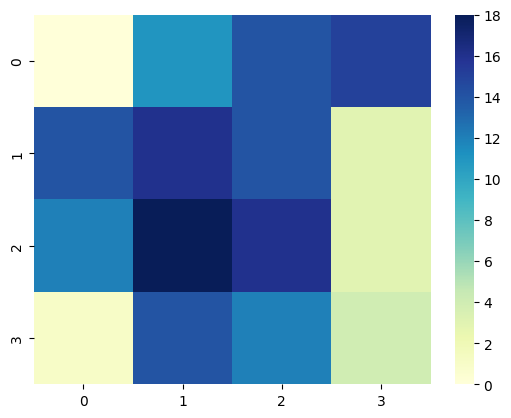

In [43]:
sns.heatmap(som.activation_response(df_scaled), cmap='YlGnBu')

Buscamos observar el valor de los pesos dados en función de cada una de las variables empleadas dentro del dataframe. Para ello, realizamos un mapa de calor indicando cuales son los valores finales tras el entrenamiento de cada peso con respecto a cada variable.

Esta visualización puede ayudar a identificar cuales son las neuronas más influyentes para la decisión de clasificación de cada valor del dataset. Otra aplicación de este gráfico puede llegar a ser el descubrimiento de relaciones no lineales entre distintas variables. Esto último puede resultar de que distintas variables presenten mapas de calor similares, teniendo pesos de alto valor en las mismas neuronas y pesos de bajo valor también en las mismas.

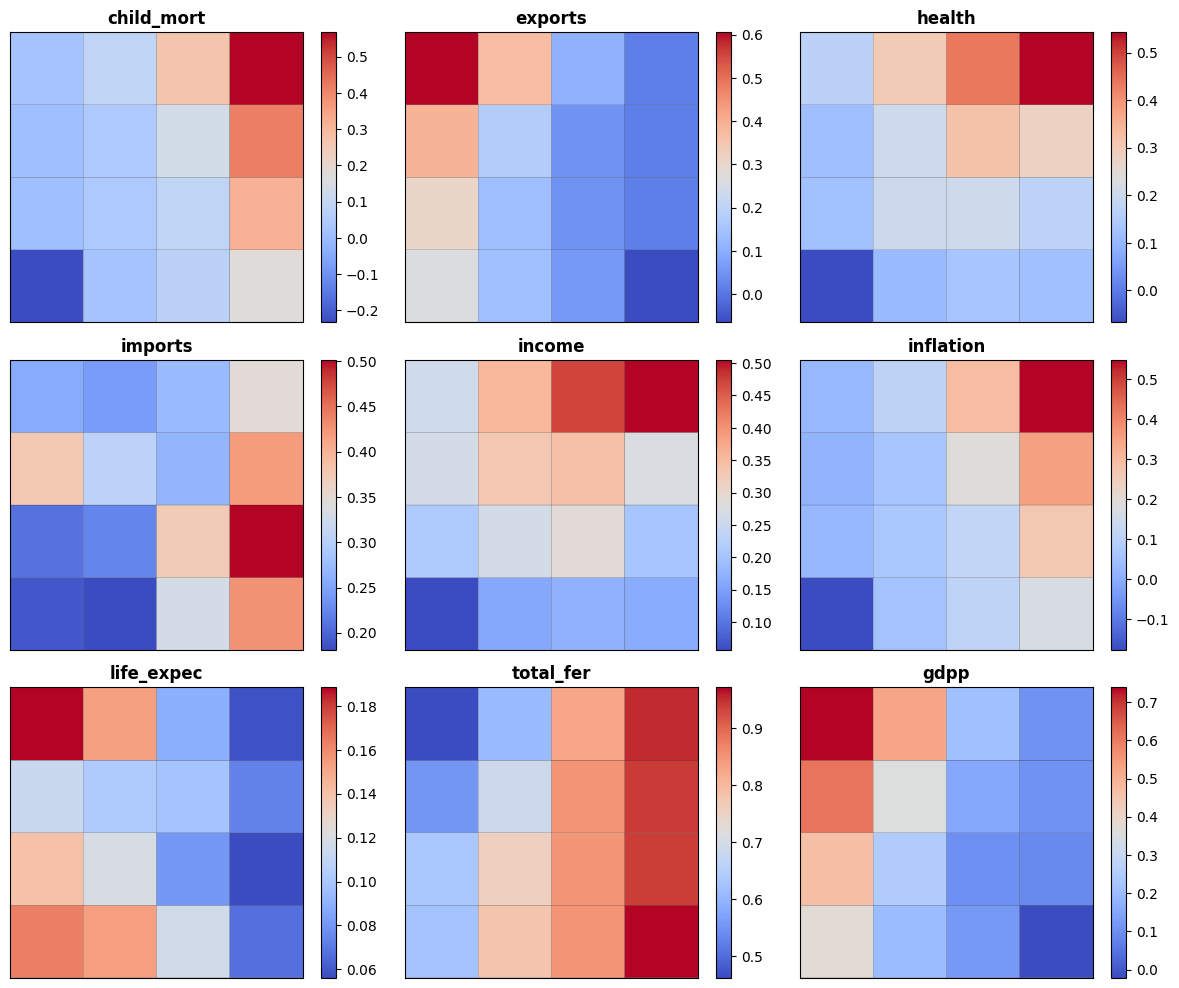

In [44]:
W = som.get_weights()
plt.figure(figsize=(12, 10))
features = df_sin_country.columns

for i, f in enumerate(features):
    plt.subplot(3, 3, i + 1)
    plt.title(f, fontsize=12, fontweight='bold')
    plt.pcolor(W[:, :, i-1].T, cmap='coolwarm', edgecolors='k', linewidths=0.1)
    plt.colorbar()
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()